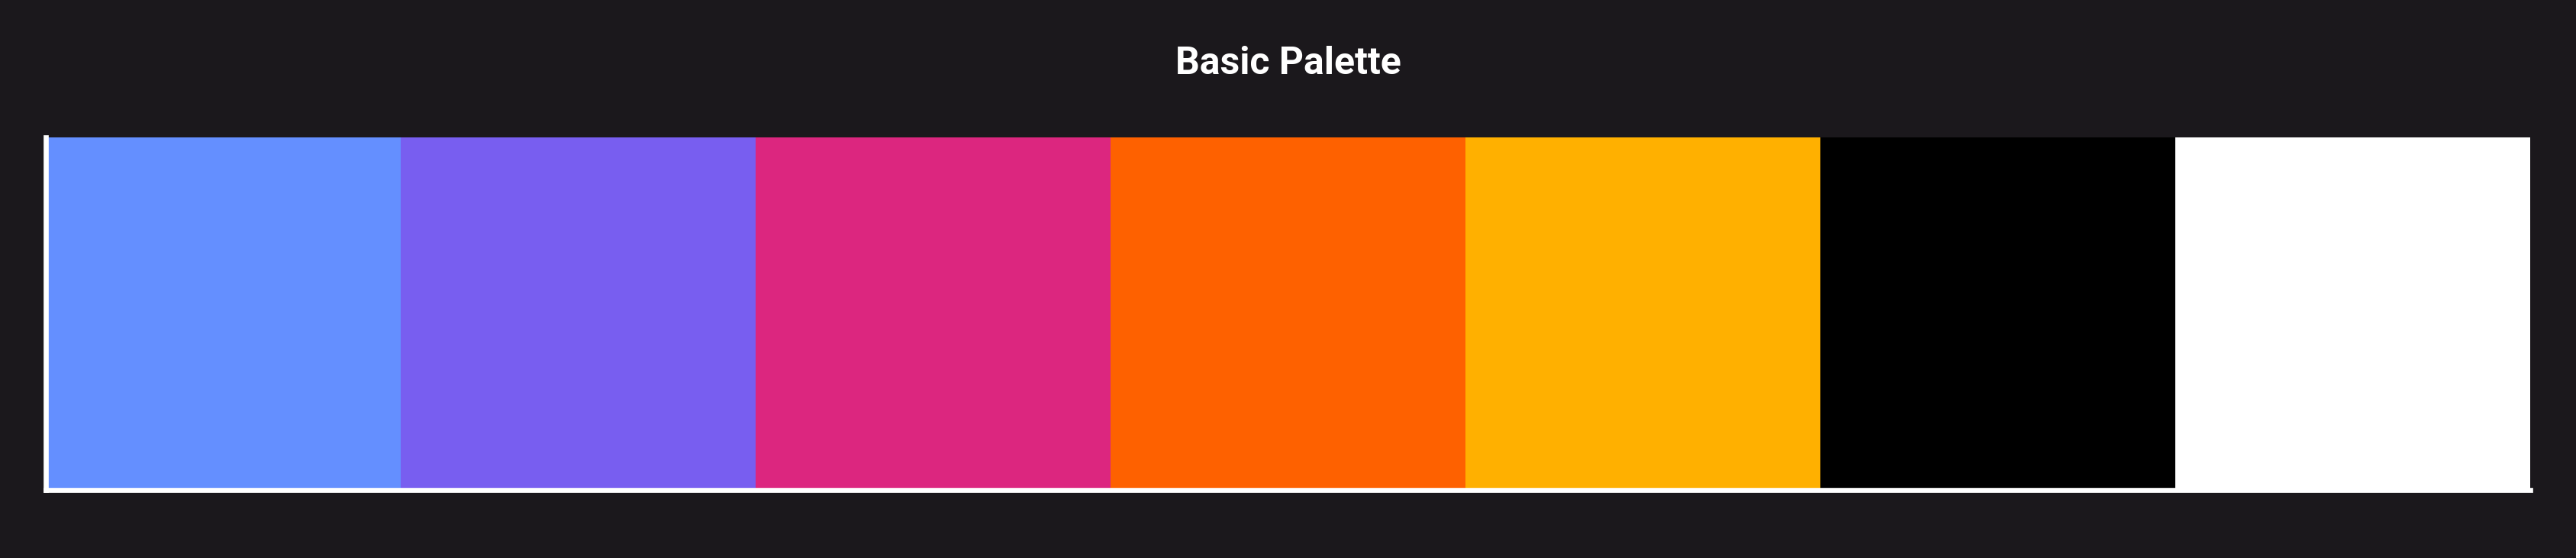

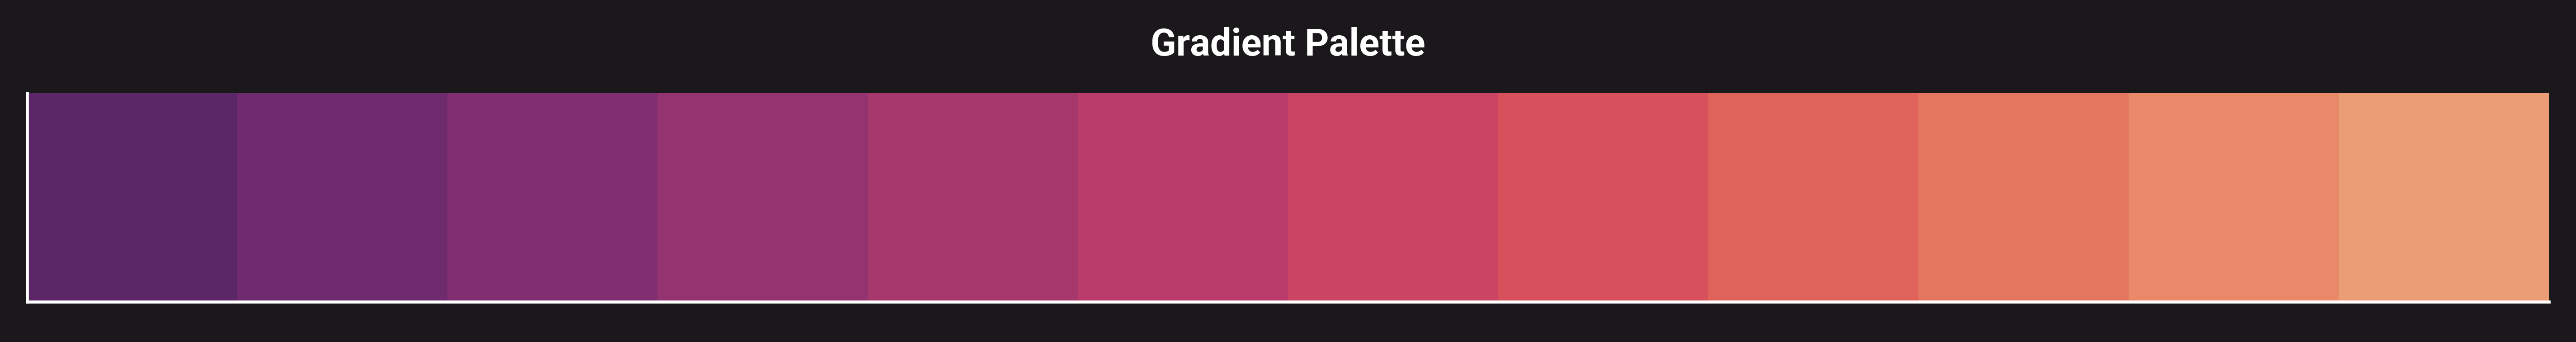

In [8]:
from data_preprocessing import ph_restos
import pandas as pd
import matplotlib as mpl
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import seaborn as sns

# @title Get fonts
fm.fontManager.addfont('Roboto/static/Roboto-Light.ttf')
fm.fontManager.addfont('Roboto/static/Roboto-Regular.ttf')
fm.fontManager.addfont('Roboto/static/Roboto-Medium.ttf')
fm.fontManager.addfont('Roboto/static/Roboto-Bold.ttf')

colors = ["#648FFF", "#785EF0", "#DC267F", "#FE6100", "#FFB000", "#000000", "#FFFFFF"]
colors_grad = sns.color_palette('flare_r',  12)
colors_heat1 = sns.color_palette('flare_r', as_cmap=True)
colors_heat2 = sns.diverging_palette(315, 261, s=74, l=50, center='dark', as_cmap=True)

color_bg = "#1B181C"
color_text = "#FFFFFF"

sns.palplot(colors)
plt.gca().set_title('Basic Palette', fontsize=6, pad=10)

sns.palplot(colors_grad)
plt.gca().set_title('Gradient Palette', fontsize=10, pad=10)

plt.show()

mpl.rcParams['figure.dpi'] = 600
mpl.rcParams["figure.figsize"] = 16,8

# Text
mpl.rcParams['font.family'] = 'Roboto'

# Title
mpl.rcParams['figure.titlesize'] = 32
mpl.rcParams['axes.titlesize'] = 32
mpl.rcParams['axes.titleweight'] = 'bold'

# Labels
mpl.rcParams['axes.labelsize'] = 22
mpl.rcParams['xtick.labelsize'] = 22
mpl.rcParams['ytick.labelsize'] = 22

# Spacing
mpl.rcParams['axes.titlepad'] = 72
mpl.rcParams['axes.labelpad'] = 10
mpl.rcParams['xtick.major.pad'] = 10
mpl.rcParams['ytick.major.pad'] = 10
mpl.rcParams['xtick.major.width'] = 0
mpl.rcParams['xtick.minor.width'] = 0
mpl.rcParams['ytick.major.width'] = 0
mpl.rcParams['ytick.minor.width'] = 0

# Spines and grids
mpl.rcParams['axes.spines.top'] = False
mpl.rcParams['axes.spines.right'] = False
mpl.rcParams['axes.grid'] = False

# Legends
mpl.rcParams['legend.title_fontsize'] = 18
mpl.rcParams['legend.fontsize'] = 18
mpl.rcParams['legend.frameon'] = False

# Bars
plt.rcParams['patch.linewidth'] = 0
plt.rcParams['patch.edgecolor'] = 'none'

# Colors
mpl.rcParams["figure.facecolor"] = color_bg
mpl.rcParams["axes.facecolor"] = color_bg
mpl.rcParams["savefig.facecolor"] = color_bg

# Text colors
mpl.rcParams['text.color'] = color_text
mpl.rcParams['axes.labelcolor'] = color_text
mpl.rcParams['xtick.color'] = color_text
mpl.rcParams['ytick.color'] = color_text

# Line colors
mpl.rcParams['axes.edgecolor'] = color_text

# of unique food types in HUC: 67
# of unique food types in rural: 59


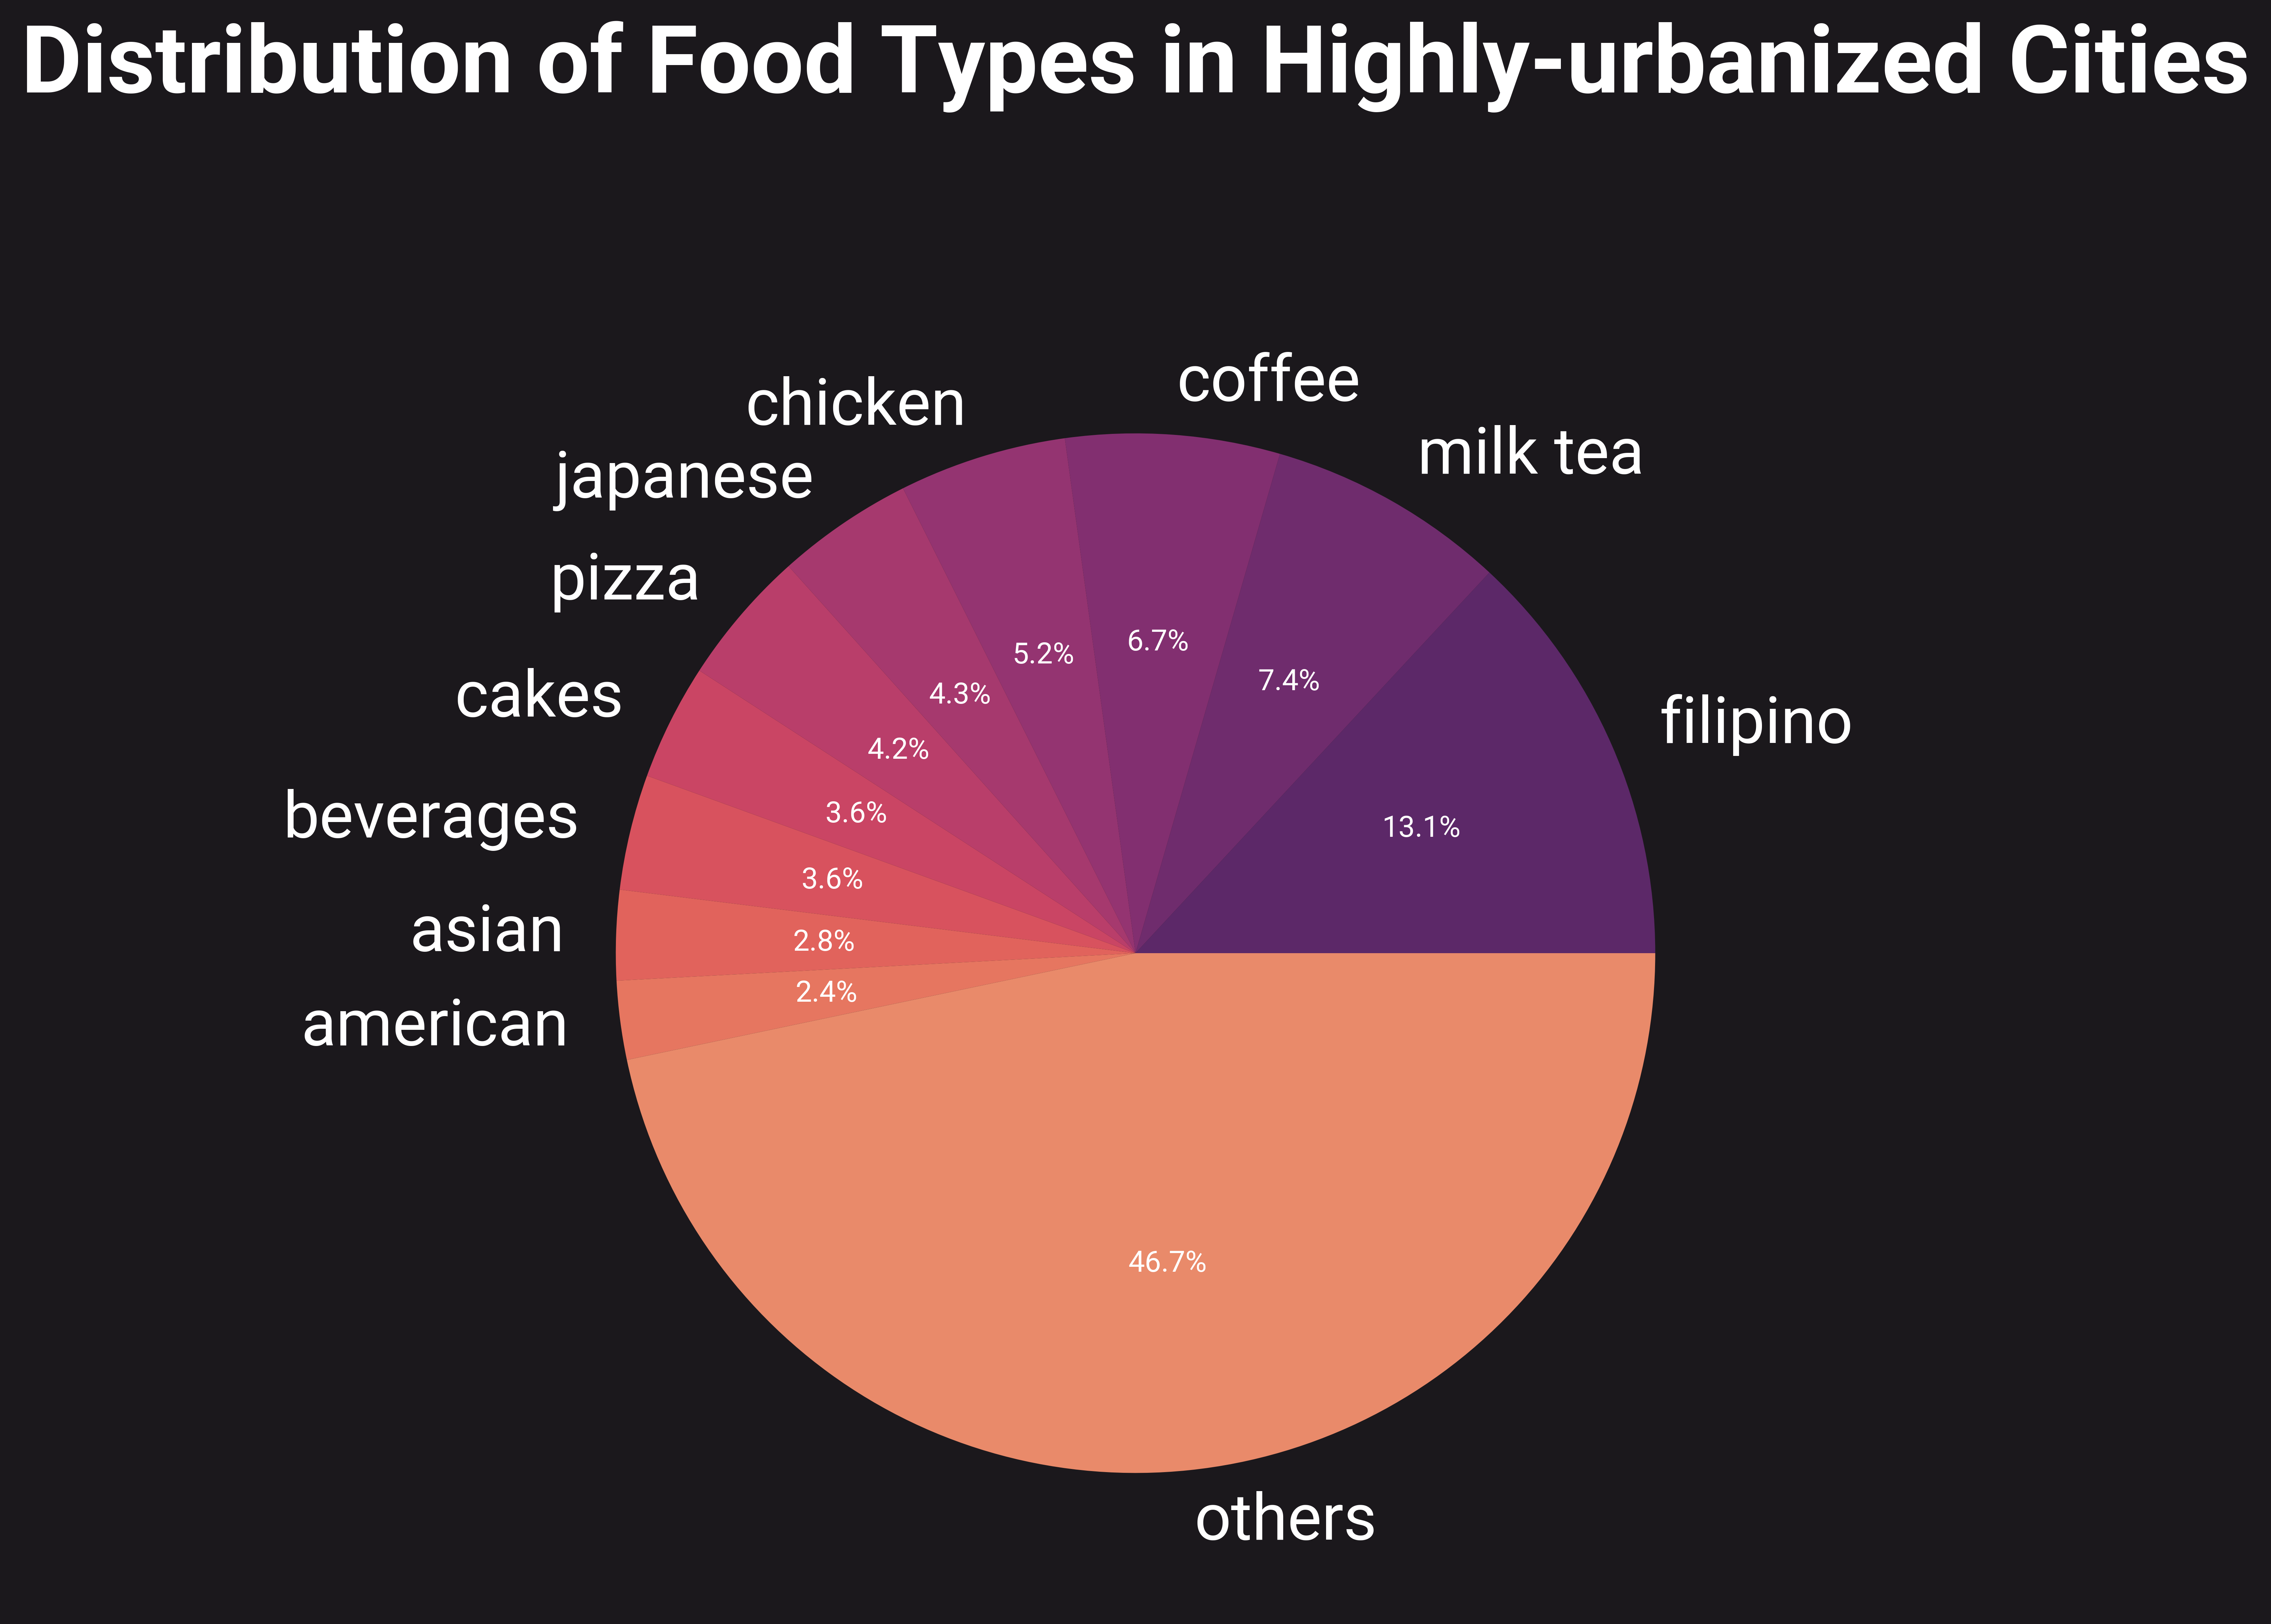

In [9]:
highly_urbanized_cities = [
    'cebu city',
    'davao city davao del sur',
    'lapu-lapu city cebu',
    'makati city',
    'mandaluyong city',
    'manila',
    'marikina',
    'muntinlupa city',
    'pasay city',
    'pasig city',
    'quezon city',
    'san juan',
    'taguig city'
]

component_cities = [
    'dagupan pangasinan',
    'koronadal south cotabato',
    'malolos bulacan',
    'ormoc leyte',
    'valencia bukidnon'
]

def label_city(vector):
    if vector["City"] in highly_urbanized_cities:
        return 1
    else:
        return 0

ph_restos["HighlyUrbanized"] = ph_restos.apply(label_city, axis=1)

highly_urbanized = ph_restos[ph_restos['HighlyUrbanized']==1]
component = ph_restos[ph_restos['HighlyUrbanized']==0]

highly_urbanized_counts = highly_urbanized["FoodType"].value_counts()
component_counts = component["FoodType"].value_counts()
print("# of unique food types in HUC:",len(highly_urbanized_counts))
print("# of unique food types in rural:",len(component_counts))

# Keep only the Top 9 and aggregate the rest in an "Others" category
n = 0
num_counts = []
label_counts = []
others_counts = 0

for index, value in highly_urbanized_counts.items():
    if n<10:
        num_counts.append(value)
        label_counts.append(index)
    else:
        others_counts += value
    n+=1
num_counts.append(others_counts)
label_counts.append("others")

highly_urbanized_top10 = pd.Series(num_counts, label_counts)
plt.pie(highly_urbanized_top10, colors=colors_grad, labels=label_counts, autopct='%1.1f%%')
plt.title(label="Distribution of Food Types in Highly-urbanized Cities")
plt.show()

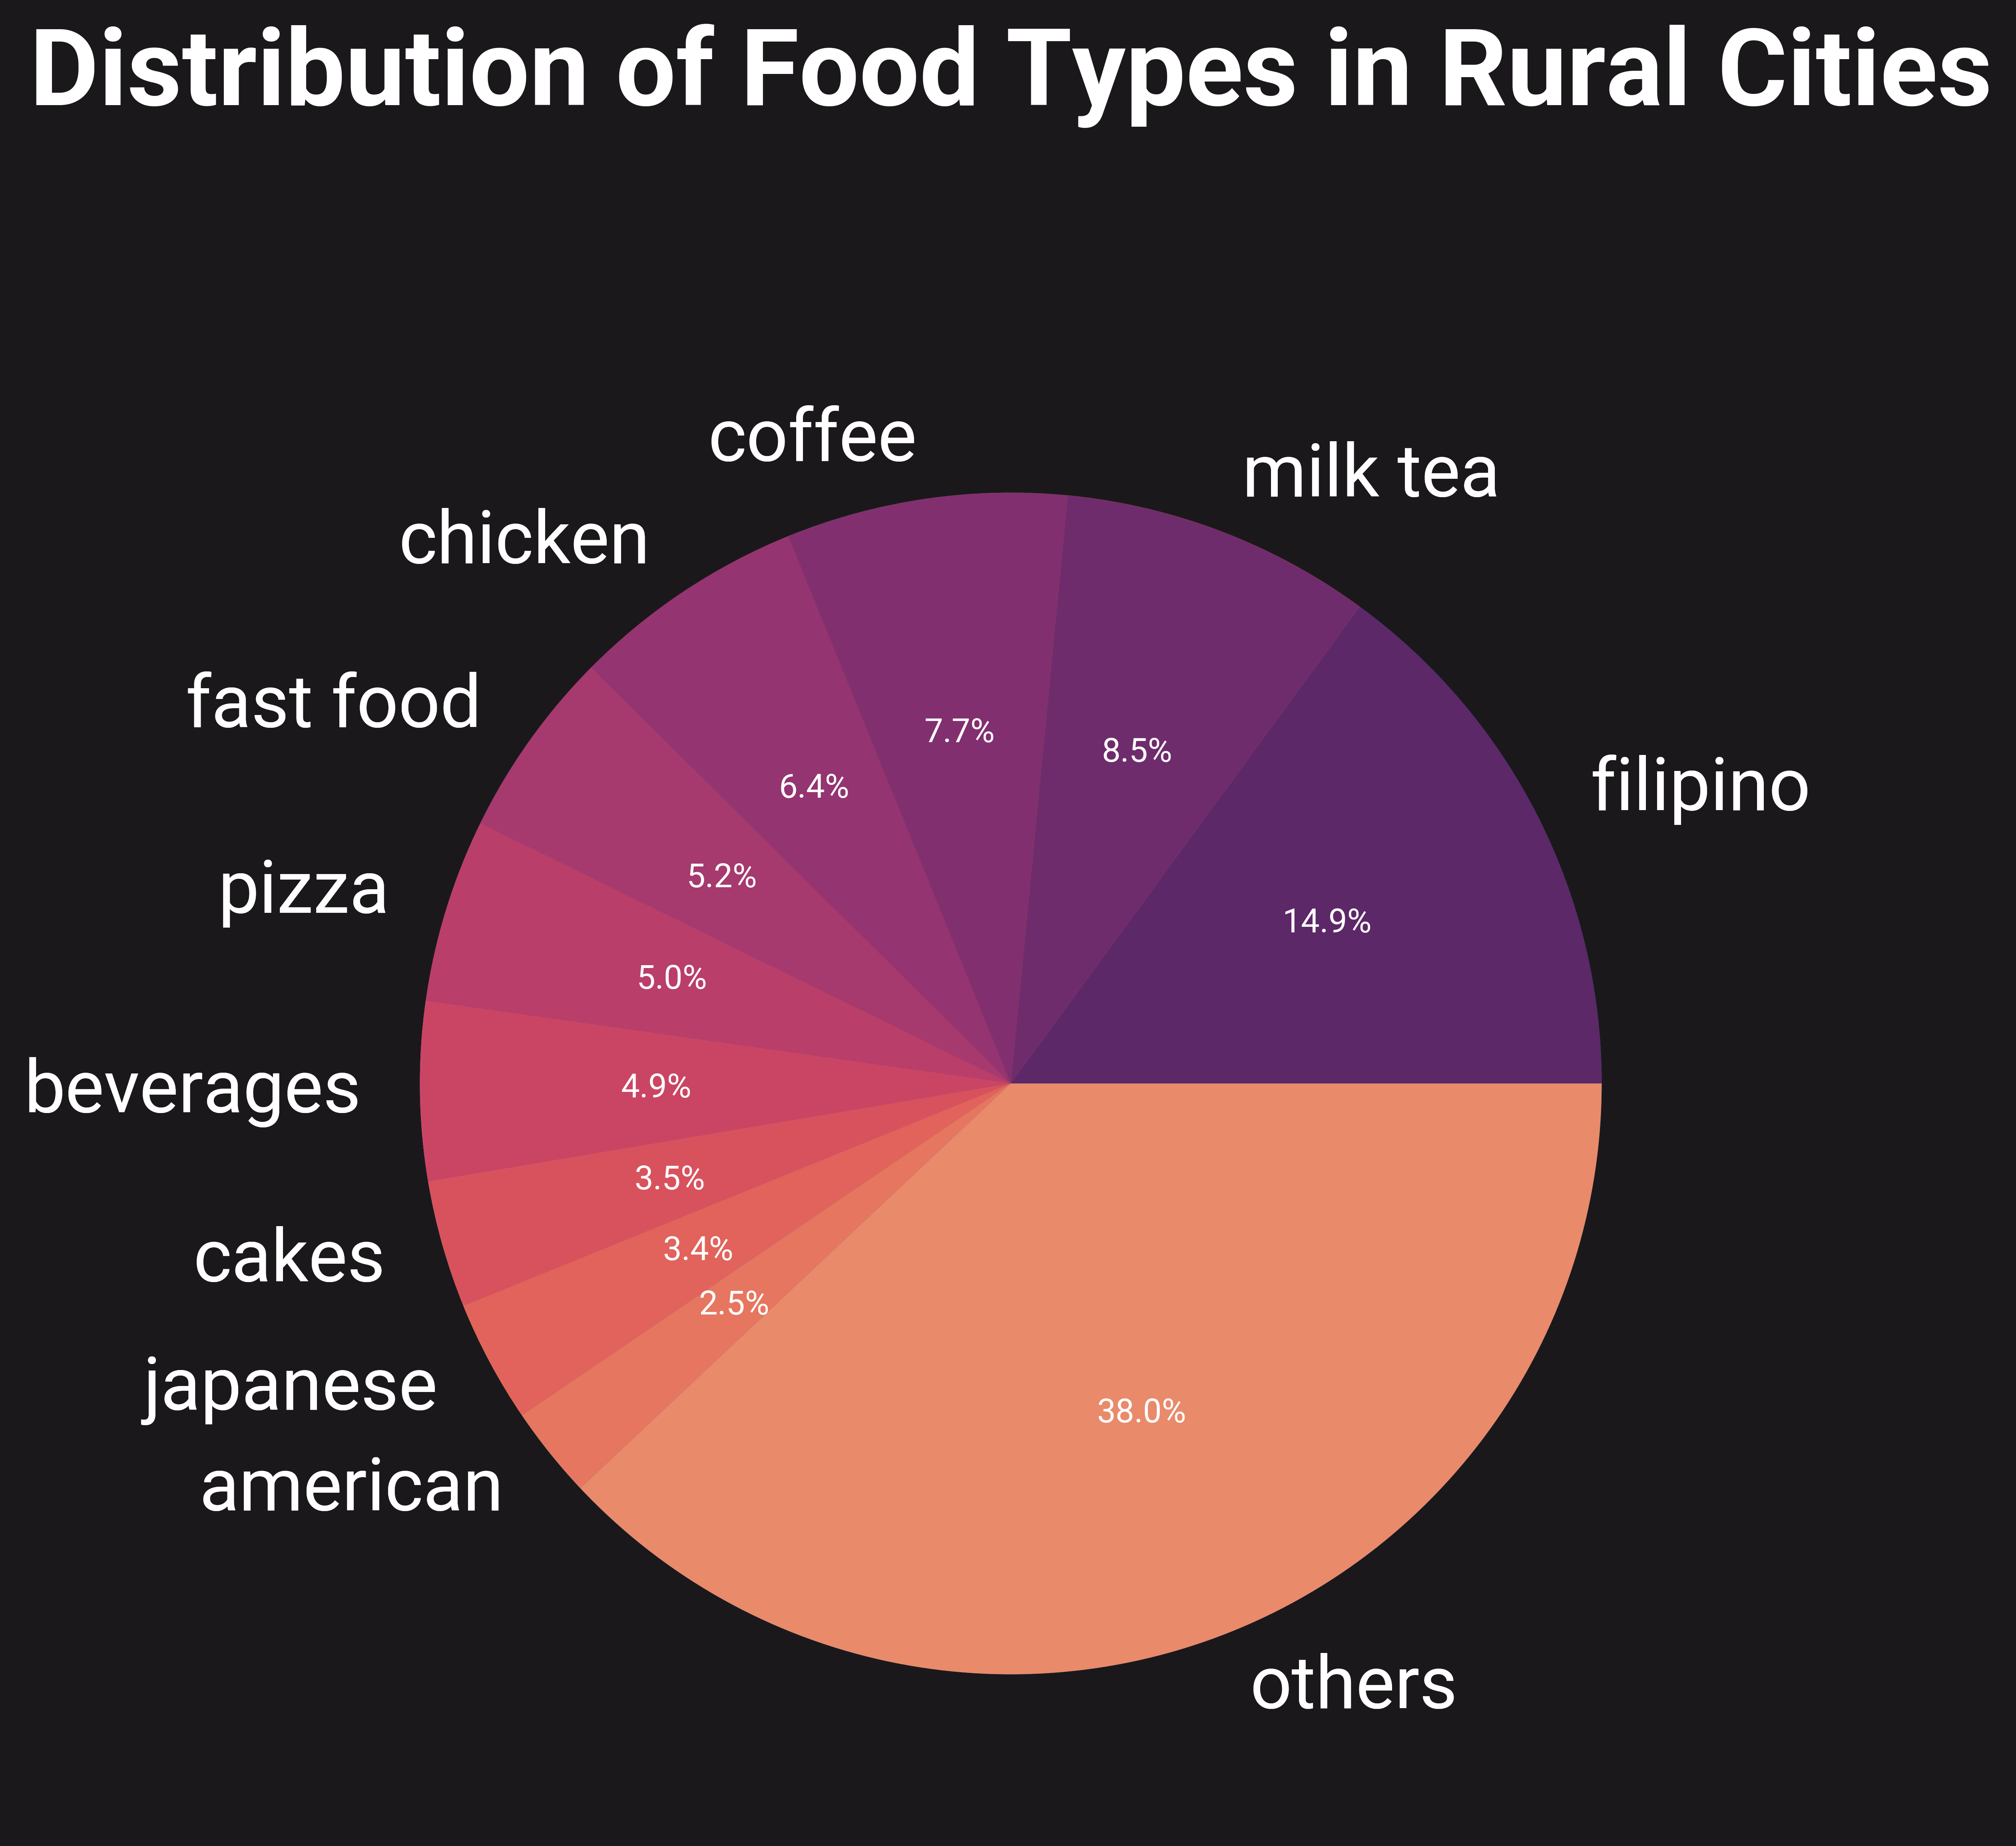

In [10]:
n = 0
num_counts = []
label_counts = []
others_counts = 0

for index, value in component_counts.items():
    if n<10:
        num_counts.append(value)
        label_counts.append(index)
    else:
        others_counts += value
    n+=1
num_counts.append(others_counts)
label_counts.append("others")

component_top10 = pd.Series(num_counts, label_counts)
component_top10.plot(kind='pie')
plt.pie(component_top10, colors=colors_grad, labels=label_counts, autopct='%1.1f%%')
plt.title(label="Distribution of Food Types in Rural Cities")
plt.show()

In [11]:
from data_preprocessing import ph_restos
# RQ 1 -- Average ratings per city
highly_urbanized_cities = [
    'cebu city',
    'davao city davao del sur',
    'lapu-lapu city cebu',
    'makati city',
    'mandaluyong city',
    'manila',
    'marikina',
    'muntinlupa city',
    'pasay city',
    'pasig city',
    'quezon city',
    'san juan',
    'taguig city'
]

component_cities = [
    'dagupan pangasinan',
    'koronadal south cotabato',
    'malolos bulacan',
    'ormoc leyte',
    'valencia bukidnon'
]

def label_city(vector):
    if vector["City"] in highly_urbanized_cities:
        return 1
    else:
        return 0

ph_restos["HighlyUrbanized"] = ph_restos.apply(label_city, axis=1)

ratings_highly_urbanized = ph_restos[ph_restos['HighlyUrbanized']==1].groupby(["City"])['AverageRating'].mean()
# print(ratings_highly_urbanized)
# print("==================")
ratings_component = ph_restos[ph_restos['HighlyUrbanized']==0].groupby(["City"])['AverageRating'].mean()
# print(ratings_component)
# print("==================")
# rating_per_city = ph_restos.groupby(["City"])['AverageRating'].mean()
# print(rating_per_city)

foodTypes_highly_urbanized = ph_restos[ph_restos['HighlyUrbanized']==1].groupby(['City'])['FoodType'].nunique()
# print(foodTypes_highly_urbanized)
foodTypes_component = ph_restos[ph_restos['HighlyUrbanized']==0].groupby(['City'])['FoodType'].nunique()

fig, axes = plt.subplots(3,2,gridspec_kw={'width_ratios': [13, 5]}, figsize=(20, 15), sharey='row')

# HUC
axes[0][0].set_title("Highly Urbanized Cities (Non-HUCs)")
axes[0][0].set_ylim(4.9,5)
axes[0][0].bar(ratings_highly_urbanized.index.values, ratings_highly_urbanized.values, color=colors[1])
axes[0][0].set_yticks(ticks=[4.8, 4.85, 4.9, 4.95, 5])
axes[0][0].set_ylabel("Average Rating (Zoomed In)")
axes[0][0].set_xticks([])

axes[1][0].bar(ratings_highly_urbanized.index.values, ratings_highly_urbanized.values, color=colors[0])
axes[1][0].set_ylabel("Average Rating")
axes[1][0].set_xticks([])


axes[2][0].bar(foodTypes_highly_urbanized.index.values, foodTypes_highly_urbanized.values, color=colors[0])
axes[2][0].set_ylabel("Number of Unique Food Types")
axes[2][0].tick_params(labelrotation=90, grid_color="r", grid_alpha=0.5)

# Non-HUC
axes[0][1].set_title("Non-highly Urbanized Cities (Non-HUCs)")
axes[0][1].set_ylim(4.9,5)
axes[0][1].bar(ratings_component.index.values, ratings_component.values, color=colors[2])
axes[0][1].set_yticks(ticks=[4.8, 4.85, 4.9, 4.95, 5])
axes[0][1].set_xticks([])

axes[1][1].bar(ratings_component.index.values, ratings_component.values, color=colors[3])
axes[1][1].set_xticks([])

axes[2][1].bar(foodTypes_component.index.values, foodTypes_component.values, color=colors[3])
axes[2][1].tick_params(labelrotation=90, grid_color="r", grid_alpha=0.5)


# statistic, pvalue = kendalltau(pop_density_per_city, rating_per_city)
# print("Correlation between pop density & average rating:", pvalue)

# plt.bar(cities, rating_per_city, color="pink")
# plt.ylim(4.9, 5)
# plt.xticks(rotation=90)
# plt.yticks(ticks=[4.8, 4.85, 4.9, 4.95, 5])
plt.show()

HUC # of Resto Types: {'manila': 62, 'marikina': 59, 'pasig city': 59, 'mandaluyong city': 59, 'muntinlupa city': 50, 'taguig city': 57, 'cebu city': 61, 'san juan': 47, 'davao city davao del sur': 61, 'pasay city': 59, 'quezon city': 62, 'lapu-lapu city cebu': 48, 'makati city': 62}
Non-HUC # of Resto Types: {'ormoc leyte': 27, 'malolos bulacan': 48, 'dagupan pangasinan': 37, 'koronadal south cotabato': 35, 'valencia bukidnon': 25}


/var/folders/pk/nvzgfc8s3_q9wxm499ztx7d40000gn/T/ipykernel_40179/89399839.py:80: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


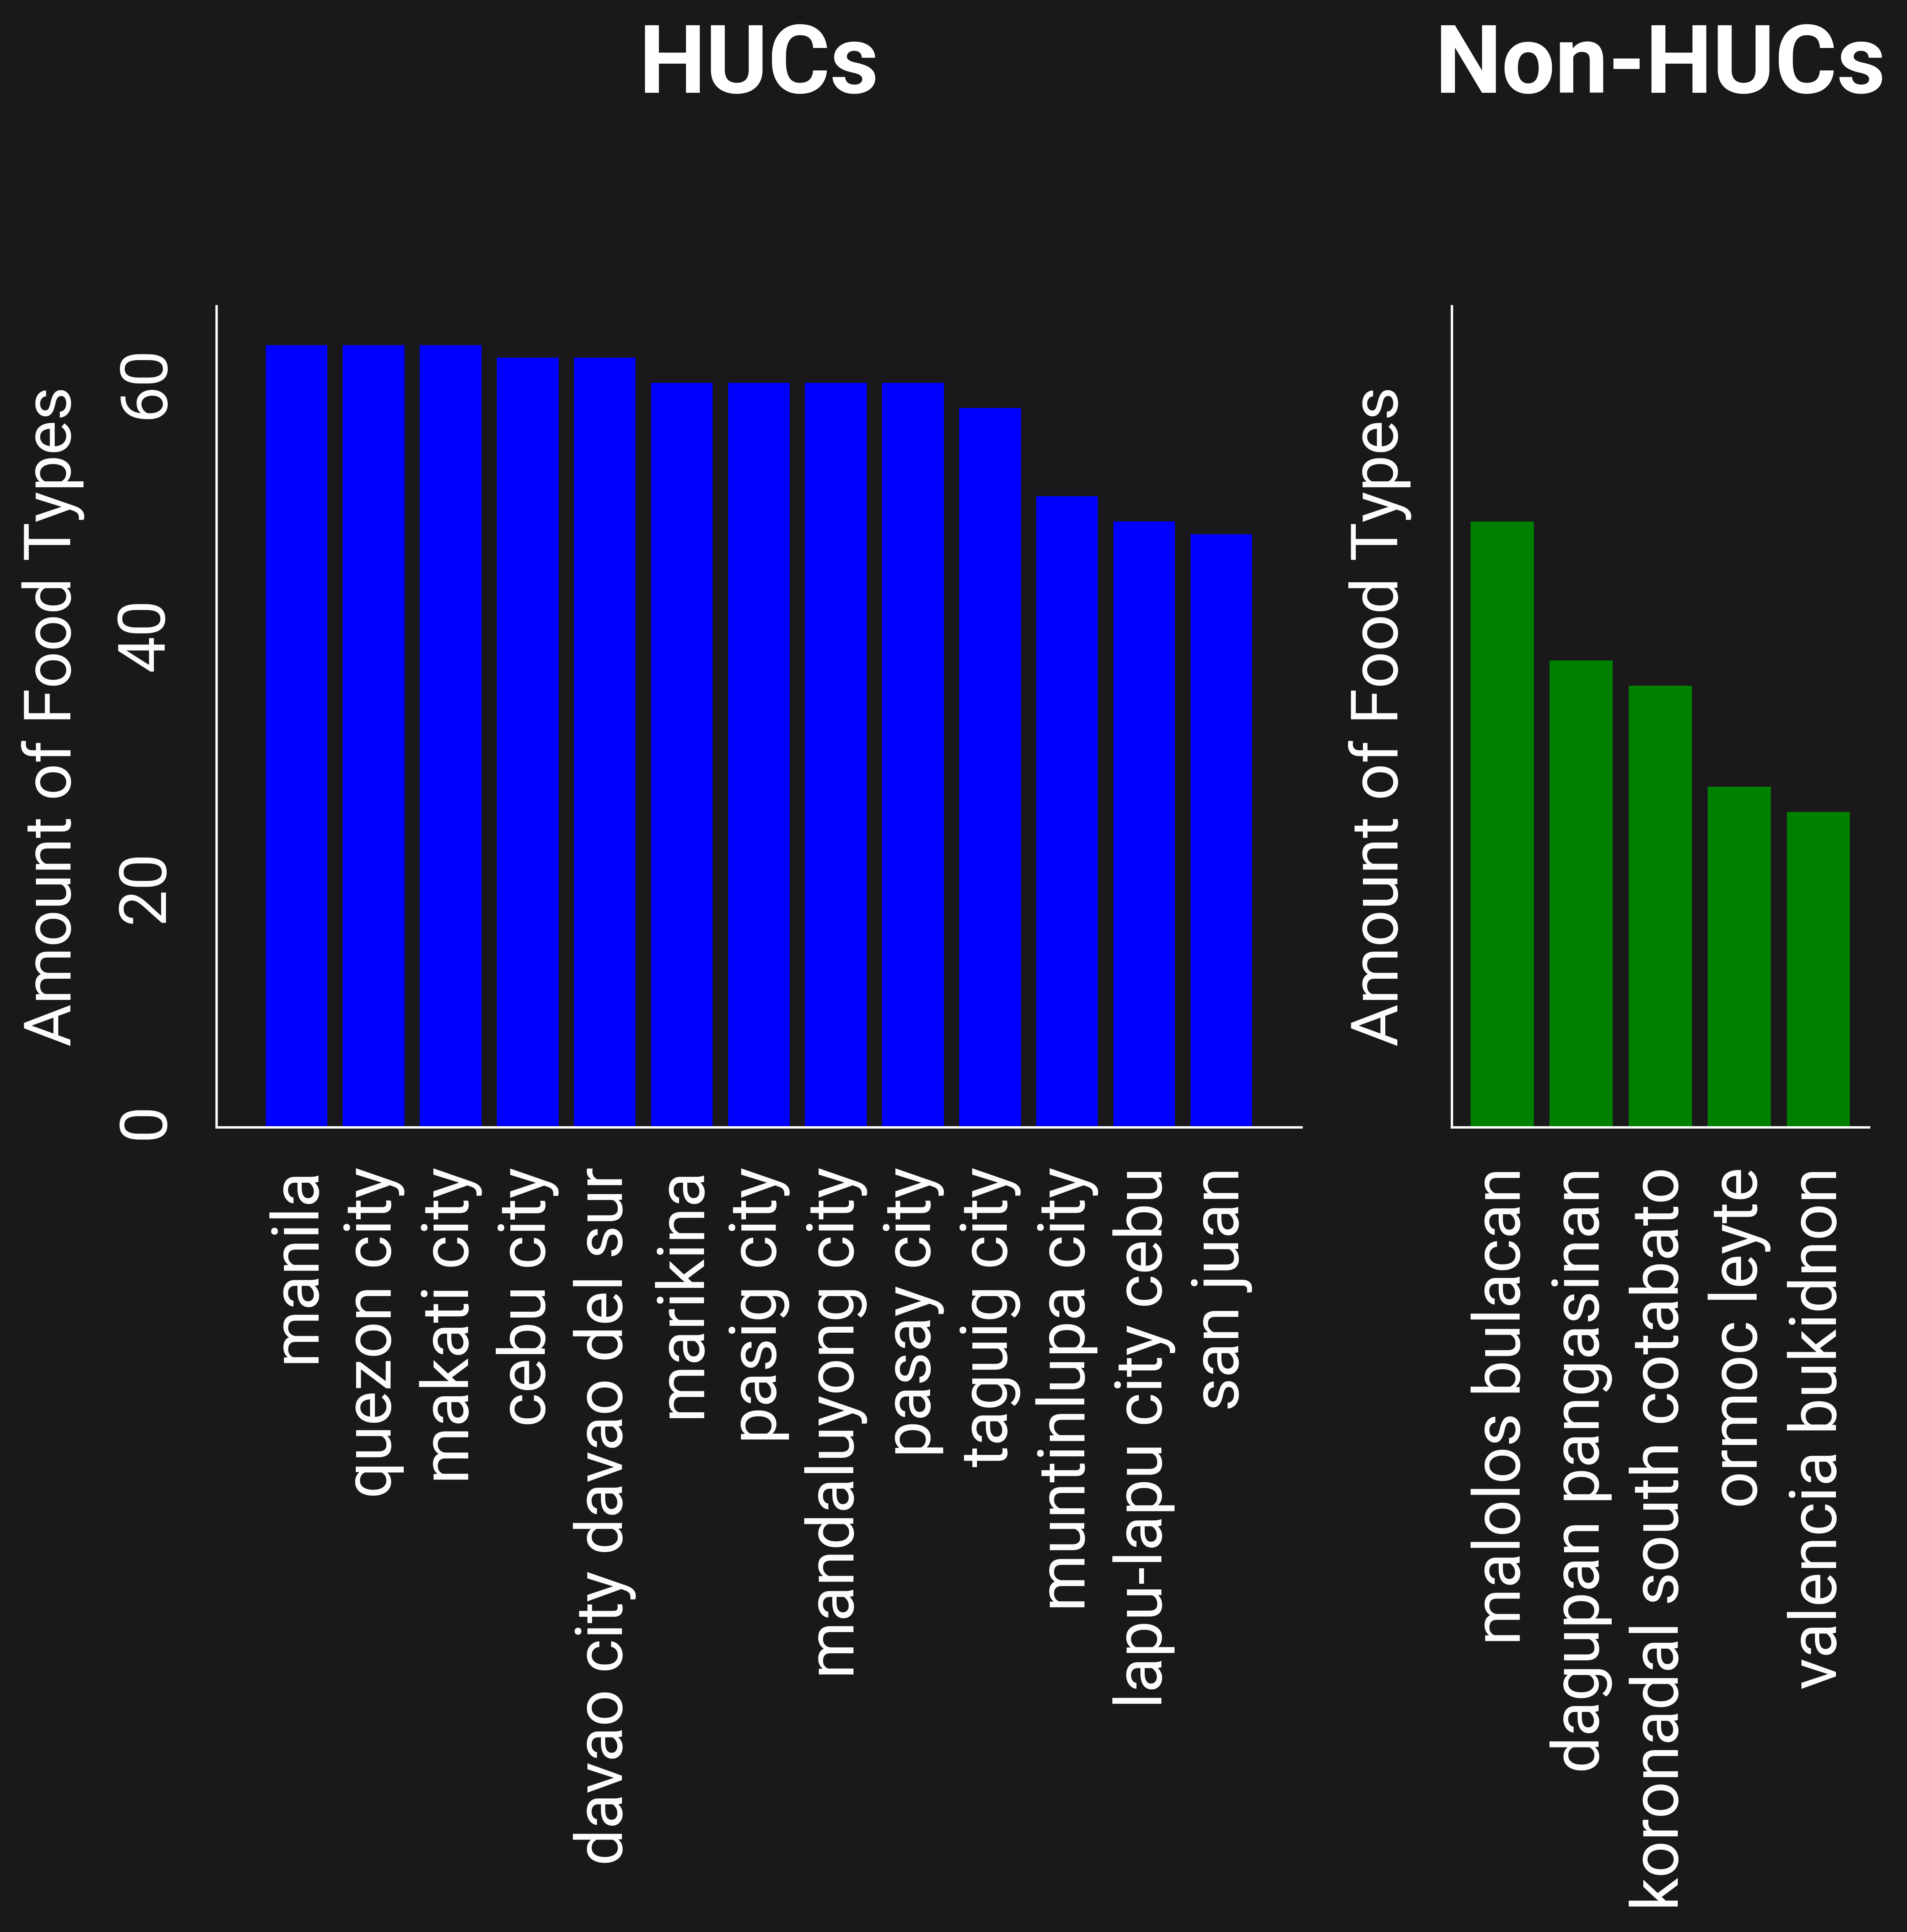

In [12]:
from data_preprocessing import ph_restos, city_pop_densities
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import mannwhitneyu, kendalltau, shapiro

cities = ph_restos["City"].unique()
rural = set(['dagupan pangasinan', 'koronadal south cotabato', 'malolos bulacan', 'ormoc leyte', 'valencia bukidnon'])
hucs = dict()
non_hucs = dict()

for city in cities:
    stores_reviews = dict()
    stores_types = dict()
    store_codes = set()

    city_types = set()

    # Gets all City Store Codes
    for index, resto in ph_restos.iterrows():
        if resto["City"] == city: 
            store_codes.add(resto["StoreId"])
            stores_reviews[resto["FoodType"]] = 0 
            stores_types[resto["StoreId"]] = resto["FoodType"]
            city_types.add(resto["FoodType"])
    
    if city in rural:
        non_hucs[city] = len(city_types)
    else:
        hucs[city] = len(city_types)

print("HUC # of Resto Types:", hucs)
print("Non-HUC # of Resto Types:", non_hucs)

huc_pairs = list(hucs.items())
non_huc_pairs = list(non_hucs.items())

huc_pairs.sort(key=lambda x: x[1], reverse=True)
non_huc_pairs.sort(key=lambda x: x[1], reverse=True)

all_pairs = huc_pairs + non_huc_pairs
cities_huc, values_huc = zip(*huc_pairs)
cities_non_huc, values_non_huc = zip(*non_huc_pairs)
_, values_all = zip(*all_pairs)

cities_huc = list(cities_huc)
values_huc = list(values_huc)
cities_non_huc = list(cities_non_huc)
values_non_huc = list(values_non_huc)
values_all = list(values_all)

# U1, p1 = mannwhitneyu(list(hucs.values()), list(non_hucs.values()), method="exact")
# print("P value of HUCs vs non-HUCs (in terms of resto types):", p1)

# all_pairs.sort(key=lambda x: x[0])
# pop_densities = list(city_pop_densities.items())
# pop_densities.sort(key=lambda x: x[0])

# _, resto_types = zip(*all_pairs)
# _, pop_density = zip(*pop_densities)
# # print(all_pairs, pop_densities)
# U2, p2 = kendalltau(pop_density, resto_types)
# print("P value of Pop Densities -> Resto Types:", p2)
# print("Shapiro-Wilk Test", shapiro(values_all).pvalue)

fig, axes = plt.subplots(1, 2, gridspec_kw={'width_ratios': [13, 5]}, figsize=(10, 5), sharey=True)

# First dataset
axes[0].bar(cities_huc, values_huc, color='blue')
axes[0].set_title("HUCs")
axes[0].set_ylabel("Amount of Food Types")
axes[0].tick_params(labelrotation=90, grid_color="r", grid_alpha=0.5)

# Second dataset
axes[1].bar(cities_non_huc, values_non_huc, color='green')
axes[1].set_title("Non-HUCs")
axes[1].set_ylabel("Amount of Food Types")
axes[1].tick_params(labelrotation=90, grid_color="r", grid_alpha=0.5)

plt.tight_layout()
plt.show()